In [1]:
#Define Imports

import abtem
import ase
from ase.cell import Cell
import numpy as np
import matplotlib.pyplot as plt
from abtem import orthogonalize_cell
from abtem import show_atoms

In [2]:
# Run the Python script for twisted bilayer structure generation
%run twisted_bilayers.py

Text(0.5, 1.0, 'WSe2')

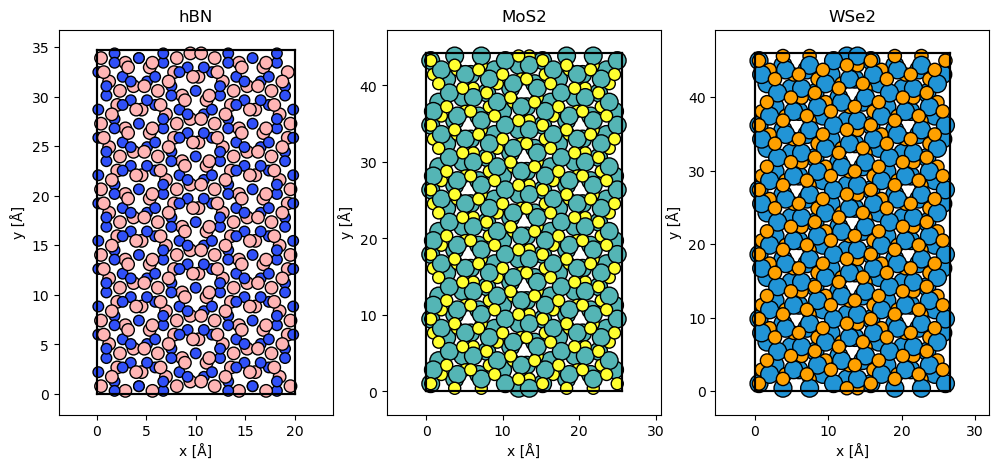

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(12,5))
show_atoms(generate_twisted_bilayers('example CIFs/BN.cif', twist_angle=21.79), plane='xy', ax=axs[0])
show_atoms(generate_twisted_bilayers('example CIFs/MoS2.cif', twist_angle=21.79), plane='xy', ax=axs[1])
show_atoms(generate_twisted_bilayers('example CIFs/WSe2.cif', twist_angle=21.79), plane='xy', ax=axs[2])
axs[0].set_title('hBN')
axs[1].set_title('MoS2')
axs[2].set_title('WSe2')

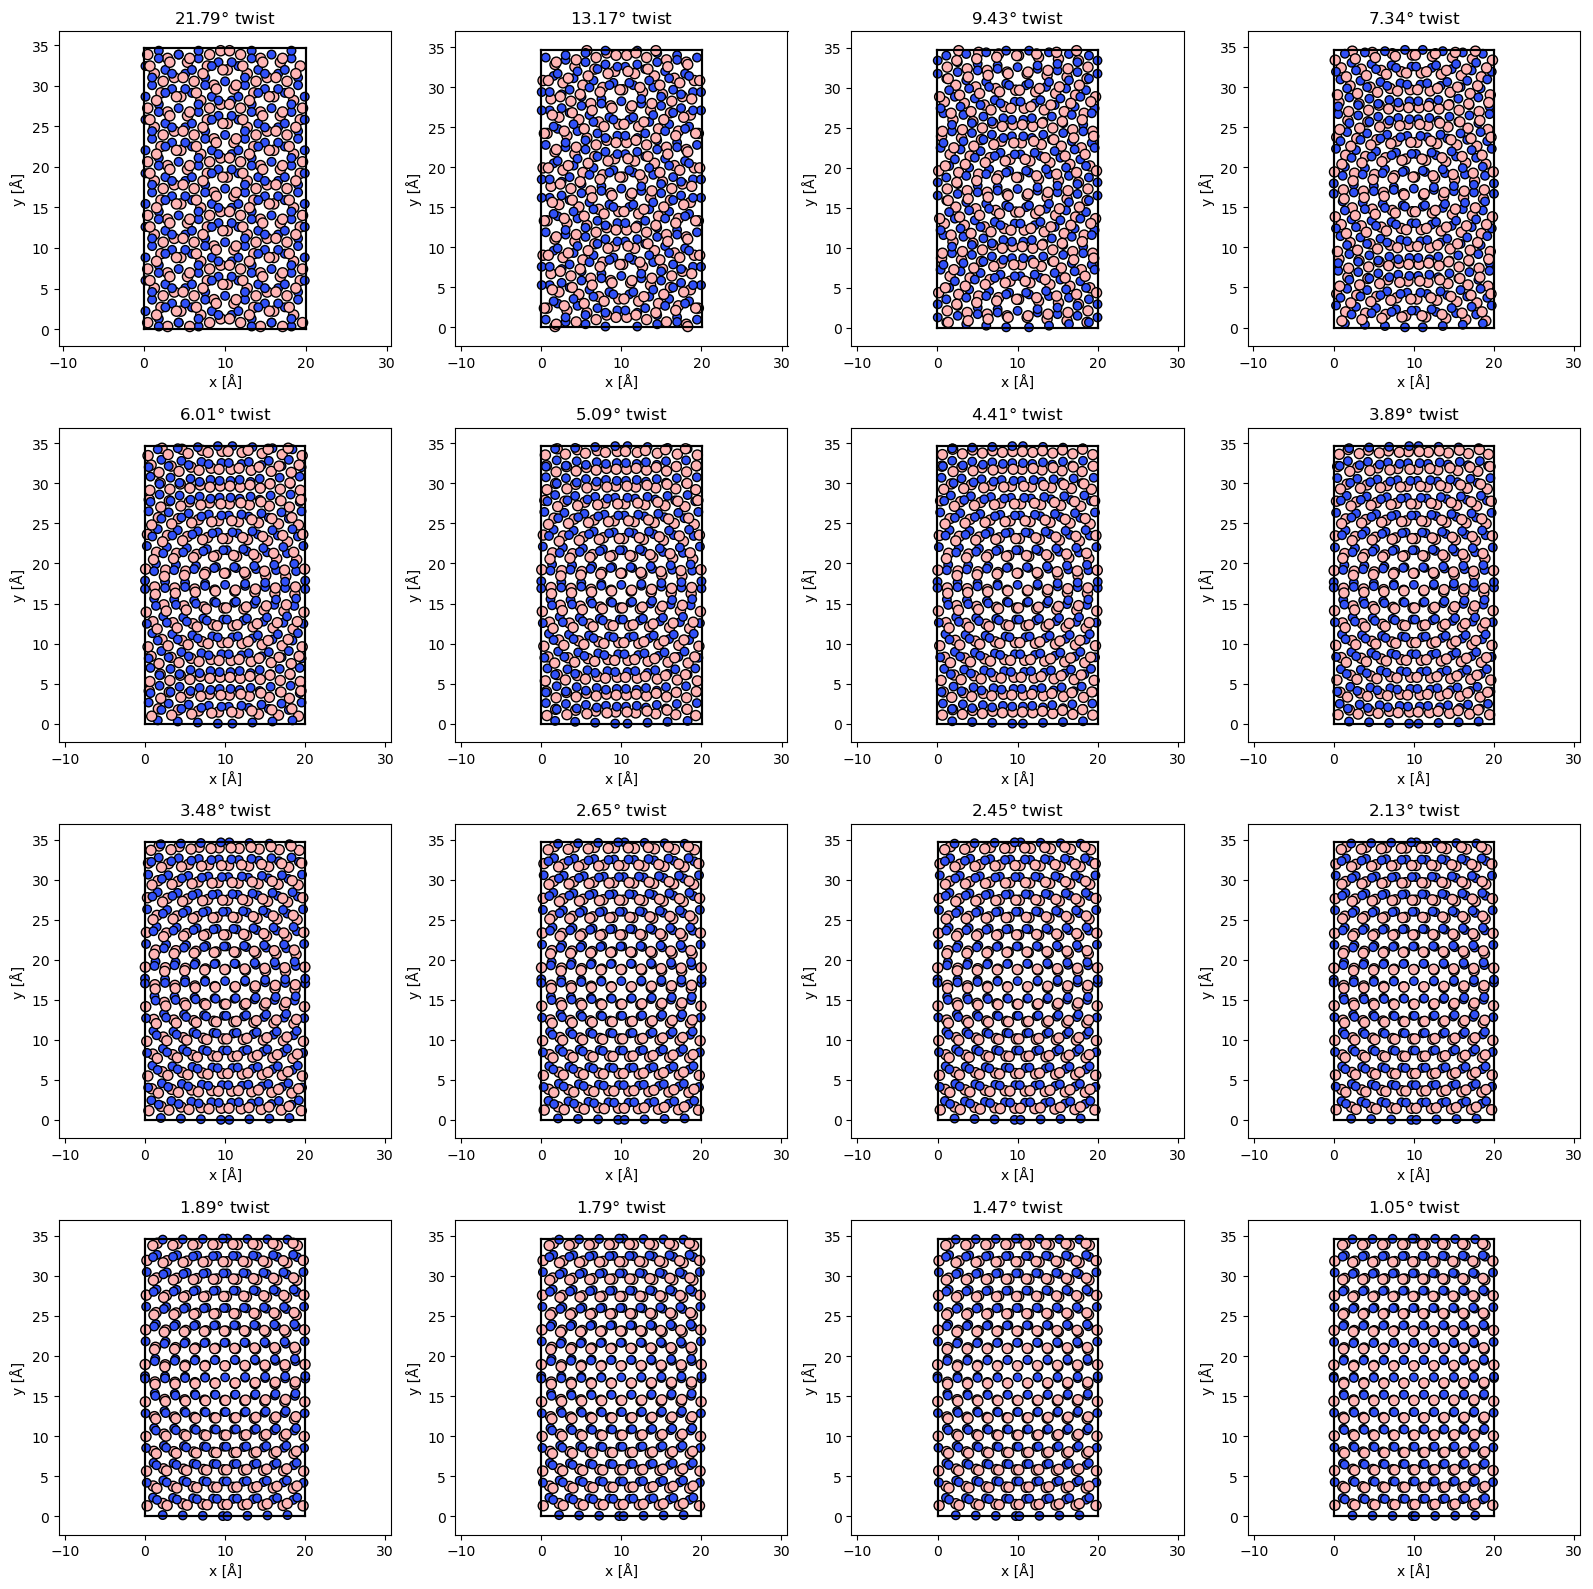

In [4]:
# Known commensurate twist angles
# Source: https://github.com/cubanpit/graphene-bilayer-dft/blob/master/graphene_bilayer_rot.py
commensurate_twist_angles_original = np.array([21.79, 13.17, 9.43, 7.34, 6.01, 5.09, 4.41, 3.89, 3.48, 2.65, 2.45, 2.13, 1.89, 1.79, 1.47, 1.05])
commensurate_twist_angles = commensurate_twist_angles_original.reshape((4,4))
fig, axs = plt.subplots(4, 4, figsize=(16,16))
structures = []

for (i,j), twist in np.ndenumerate(commensurate_twist_angles):
    structures.append(generate_twisted_bilayers('example CIFs/BN.cif', twist_angle=twist))
    show_atoms(generate_twisted_bilayers('example CIFs/BN.cif', twist_angle=twist), plane='xy', ax=axs[i,j])
    axs[i,j].set_title(f'{twist}$\degree$ twist')

plt.tight_layout()
plt.show()

In [5]:
print(structures)

[Atoms(symbols='B249N260', pbc=[True, True, False], cell=[20.013116240000002, 34.663734145461824, 7.684660085], spacegroup_kinds=...), Atoms(symbols='B254N262', pbc=[True, True, False], cell=[20.013116240000002, 34.663734145461824, 7.684660085], spacegroup_kinds=...), Atoms(symbols='B254N262', pbc=[True, True, False], cell=[20.013116240000002, 34.663734145461824, 7.684660085], spacegroup_kinds=...), Atoms(symbols='B256N258', pbc=[True, True, False], cell=[20.013116240000002, 34.663734145461824, 7.684660084999999], spacegroup_kinds=...), Atoms(symbols='B256N258', pbc=[True, True, False], cell=[20.013116240000002, 34.663734145461824, 7.684660085], spacegroup_kinds=...), Atoms(symbols='B256N258', pbc=[True, True, False], cell=[20.013116240000002, 34.663734145461824, 7.684660085], spacegroup_kinds=...), Atoms(symbols='B256N258', pbc=[True, True, False], cell=[20.013116240000002, 34.663734145461824, 7.684660084999999], spacegroup_kinds=...), Atoms(symbols='B256N258', pbc=[True, True, False]

In [6]:
from PIL import Image
potential_list = []


for i in range(len(commensurate_twist_angles_original)):
    frozen_phonons = abtem.FrozenPhonons(
        structures[i],
        num_configs=8,
        sigmas={'B': 0.1, 'N': 0.1},  # LOOK UP thermal displacement in Å
    )


    # TASK 1: Create the Potential object
    # Use sampling=0.1 Å, slice_thickness=2.0 Å, and the 'kirkland' parametrization
    potential = abtem.Potential(
        frozen_phonons,
        sampling=0.1,           # real-space sampling in Å/pixel
        slice_thickness=2.0,    # thickness of each projected slice in Å
        parametrization='kirkland',
    )
    potential_list.append(potential)
    #img = potential.project().show(cmap='viridis'); #make into gif later

print(potential_list)

[<abtem.potentials.iam.Potential object at 0x15ee43c10>, <abtem.potentials.iam.Potential object at 0x169103d90>, <abtem.potentials.iam.Potential object at 0x169bdb110>, <abtem.potentials.iam.Potential object at 0x169bf4b50>, <abtem.potentials.iam.Potential object at 0x168f0e310>, <abtem.potentials.iam.Potential object at 0x1691b76d0>, <abtem.potentials.iam.Potential object at 0x169c0b690>, <abtem.potentials.iam.Potential object at 0x169c25090>, <abtem.potentials.iam.Potential object at 0x169c36a90>, <abtem.potentials.iam.Potential object at 0x169c543d0>, <abtem.potentials.iam.Potential object at 0x169c69e50>, <abtem.potentials.iam.Potential object at 0x169c7f850>, <abtem.potentials.iam.Potential object at 0x169c992d0>, <abtem.potentials.iam.Potential object at 0x169caecd0>, <abtem.potentials.iam.Potential object at 0x169cc8790>, <abtem.potentials.iam.Potential object at 0x169cde1d0>]


tasks:   0%|          | 0/25 [00:00<?, ?it/s]

tasks:   0%|          | 0/25 [00:00<?, ?it/s]

tasks:   0%|          | 0/25 [00:00<?, ?it/s]

tasks:   0%|          | 0/25 [00:00<?, ?it/s]

tasks:   0%|          | 0/25 [00:00<?, ?it/s]

...

tasks:   0%|          | 0/25 [00:00<?, ?it/s]

tasks:   0%|          | 0/25 [00:00<?, ?it/s]

tasks:   0%|          | 0/25 [00:00<?, ?it/s]

Saved 16 frames to 'dp_frames'
Moviepy - Building video diffraction_animation.mp4.
Moviepy - Writing video diffraction_animation.mp4



Moviepy - Done !
Moviepy - video ready diffraction_animation.mp4
MoviePy - Building file diffraction_animation.gif with imageio.


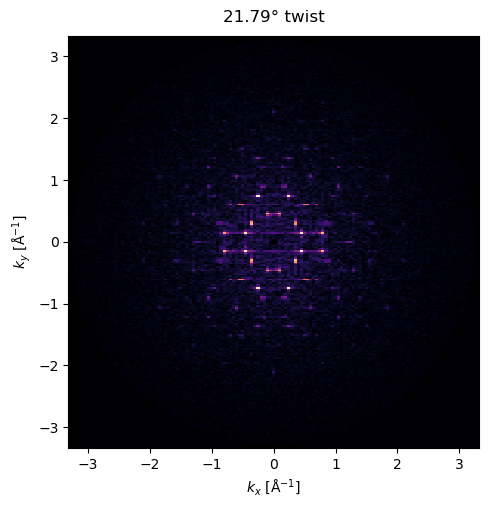

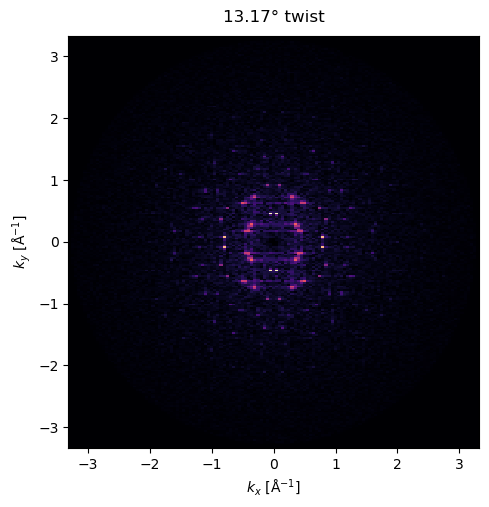

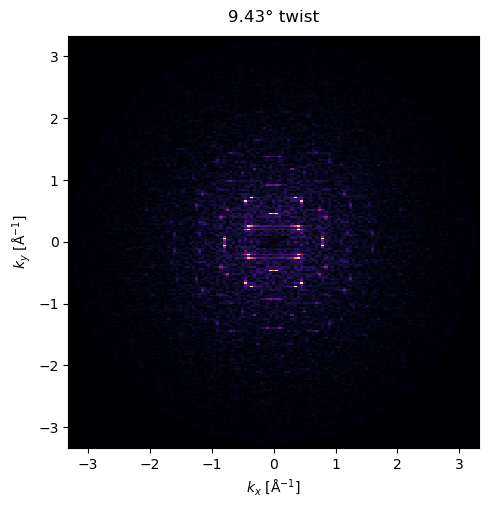

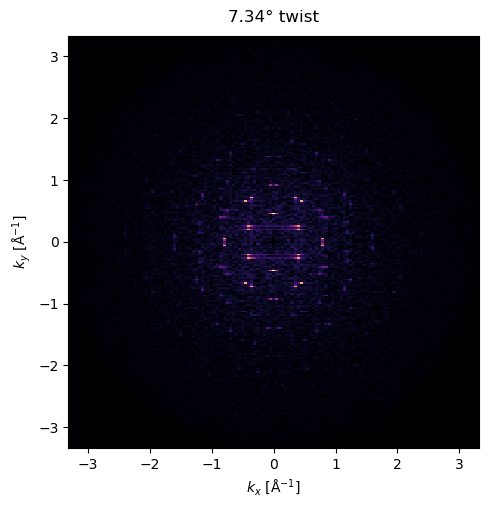

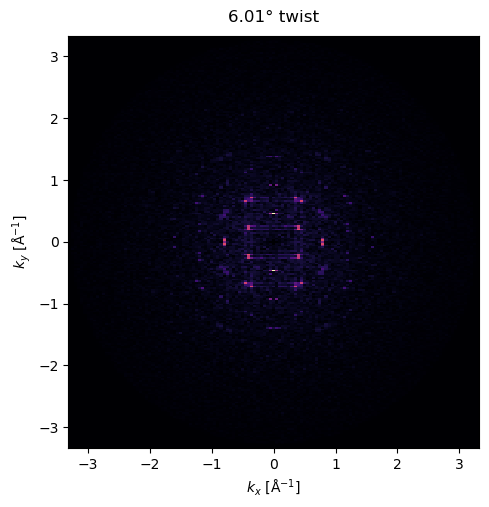

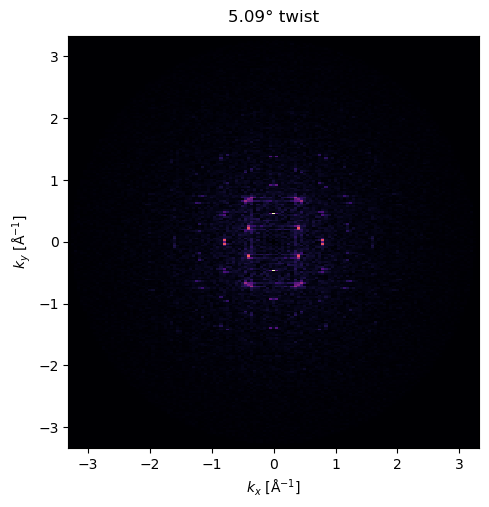

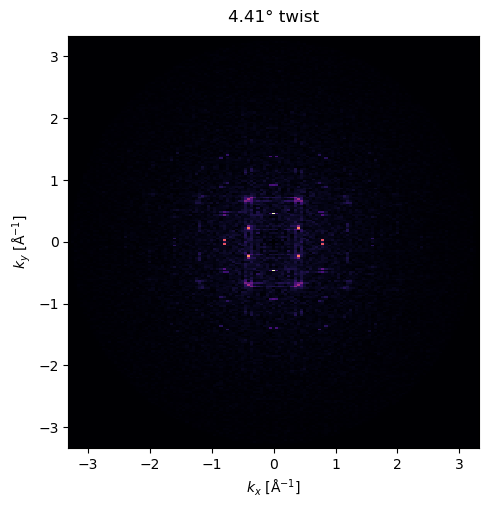

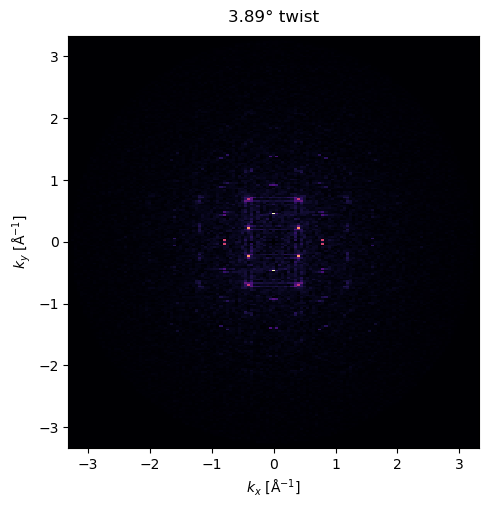

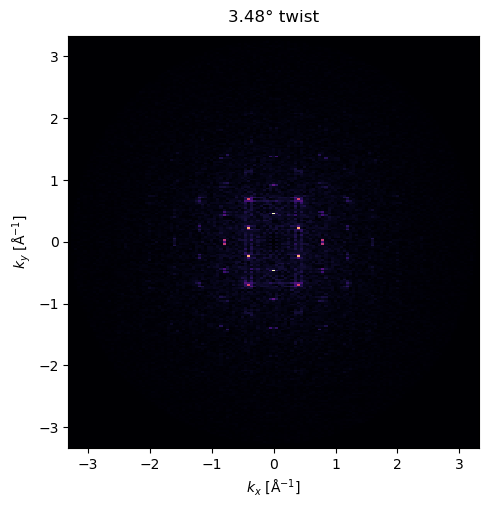

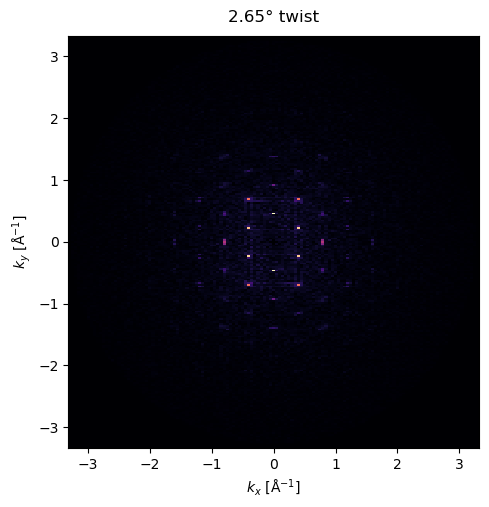

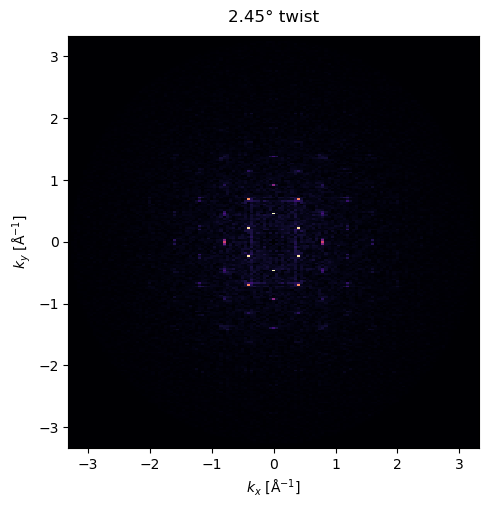

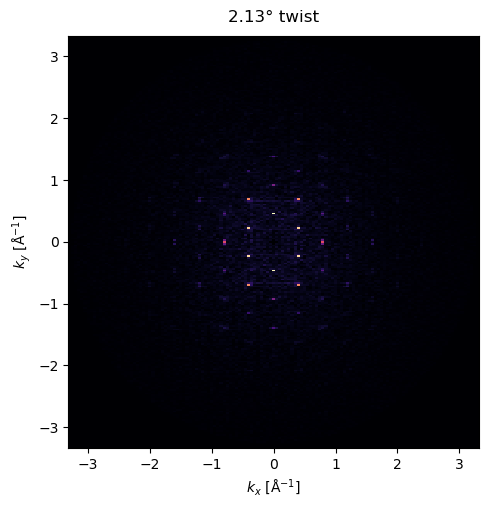

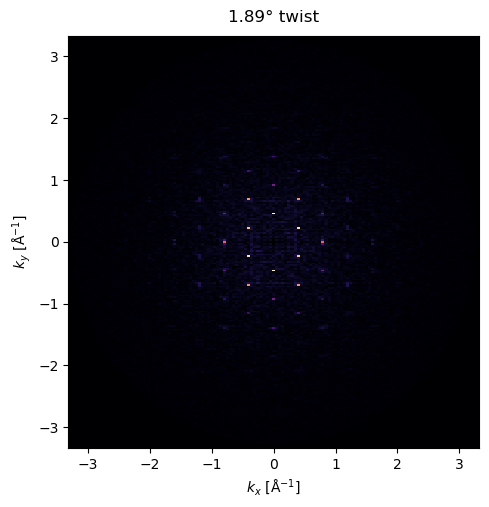

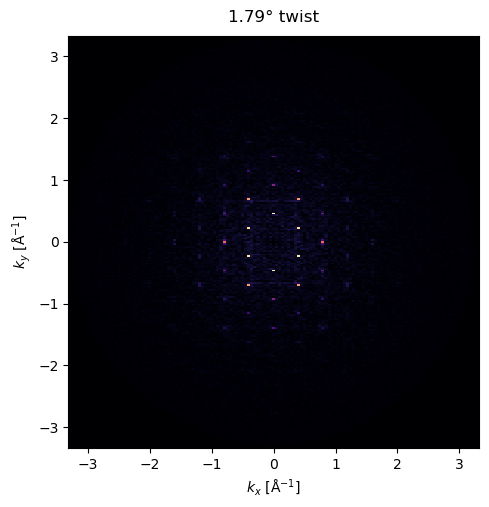

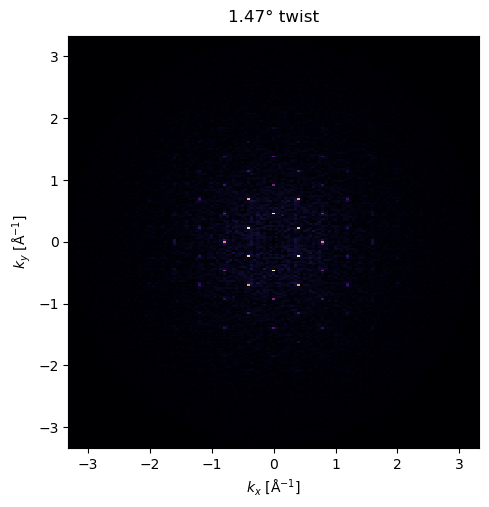

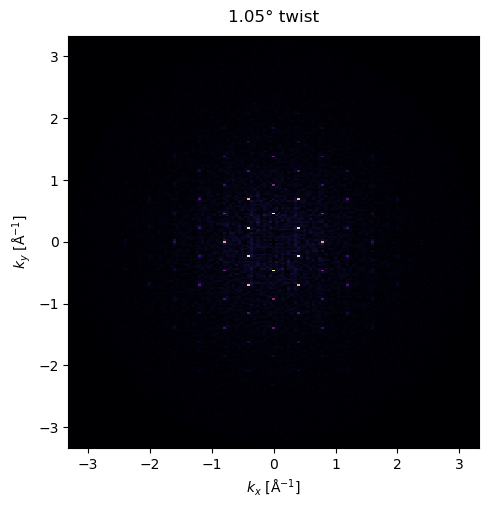

In [45]:
wave = abtem.PlaneWave(energy=300e3)  # energy in eV

out_dir = "dp_frames"
dp_list = []
dp_frame_paths = []

for i, angle in enumerate(commensurate_twist_angles_original):
    exit_wave = wave.multislice(potential_list[i])
    measurement = exit_wave.diffraction_patterns()
    dp_list.append(measurement)
    title = f"{angle}° twist"
    img = measurement.block_direct().show(power=0.4, title=title, cmap='magma');
    figure = img.get_figure()

    frame_path = os.path.join(out_dir, f"dp_{i:03d}_{angle}deg.png")

    figure.savefig(frame_path, bbox_inches='tight')

    plt.tight_layout(pad=0)

    dp_frame_paths.append(frame_path)

print(f"Saved {len(dp_frame_paths)} frames to '{out_dir}'")

# === Build the animation ===
fps = 4  # change as you like
clip = ImageSequenceClip(dp_frame_paths, fps=fps)
clip.write_videofile("diffraction_animation.mp4", codec="libx264", audio=False)

# Optional: also make a GIF (bigger file)
clip.write_gif("diffraction_animation.gif", fps=fps)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from moviepy.editor import ImageSequenceClip  # pip install moviepy

out_dir = "dp_frames"
os.makedirs(out_dir, exist_ok=True)

wave = abtem.PlaneWave(energy=300e3)  # energy in eV
dp_frame_paths = []

for i, angle in enumerate(commensurate_twist_angles_original):
    # Run multislice and compute diffraction pattern for this angle
    exit_wave = wave.multislice(potential_list[i])
    measurement = exit_wave.diffraction_patterns()

    # Block the central beam (like you had), and convert to a numeric 2D array
    dp = measurement.block_direct()

    # Many abTEM arrays have an ensemble/config axis. Reduce to 2D:
    arr = dp.array if hasattr(dp, "array") else np.asarray(dp)
    print(arr)
    if arr.ndim == 3:
        # assume axis 0 is ensemble/config; average over it
        arr2d = arr.mean(axis=0)
        
    elif arr.ndim == 2:
        arr2d = arr
    else:
        raise ValueError(f"Unexpected dp shape: {arr.shape}. Expect 2D or 3D with ensemble.")

    # Render with Matplotlib using the same visualization choices
    fig, ax = plt.subplots(figsize=(5, 5), dpi=200)
    im = ax.imshow(arr2d**0.5, cmap='viridis', origin='upper')  # power=0.5 gamma-like
    ax.set_axis_off()
    ax.set_title(f"{angle}° twist", pad=6)

    frame_path = os.path.join(out_dir, f"dp_{i:03d}_{angle}deg.png")
    plt.tight_layout(pad=0)
    fig.savefig(frame_path, bbox_inches='tight', pad_inches=0)
    plt.close(fig)
 
    dp_frame_paths.append(frame_path)

print(f"Saved {len(dp_frame_paths)} frames to '{out_dir}'")

# === Build the animation ===
fps = 4  # change as you like
clip = ImageSequenceClip(dp_frame_paths, fps=fps)
clip.write_videofile("diffraction_animation.mp4", codec="libx264", audio=False)

# Optional: also make a GIF (bigger file)
clip.write_gif("diffraction_animation.gif", fps=fps)

dask.array<_bandlimit, shape=(8, 133, 231), dtype=float32, chunksize=(1, 133, 231), chunktype=numpy.ndarray>
dask.array<_bandlimit, shape=(8, 133, 231), dtype=float32, chunksize=(1, 133, 231), chunktype=numpy.ndarray>
dask.array<_bandlimit, shape=(8, 133, 231), dtype=float32, chunksize=(1, 133, 231), chunktype=numpy.ndarray>
dask.array<_bandlimit, shape=(8, 133, 231), dtype=float32, chunksize=(1, 133, 231), chunktype=numpy.ndarray>
dask.array<_bandlimit, shape=(8, 133, 231), dtype=float32, chunksize=(1, 133, 231), chunktype=numpy.ndarray>
dask.array<_bandlimit, shape=(8, 133, 231), dtype=float32, chunksize=(1, 133, 231), chunktype=numpy.ndarray>
dask.array<_bandlimit, shape=(8, 133, 231), dtype=float32, chunksize=(1, 133, 231), chunktype=numpy.ndarray>
dask.array<_bandlimit, shape=(8, 133, 231), dtype=float32, chunksize=(1, 133, 231), chunktype=numpy.ndarray>
dask.array<_bandlimit, shape=(8, 133, 231), dtype=float32, chunksize=(1, 133, 231), chunktype=numpy.ndarray>
dask.array<_bandlim

Moviepy - Done !
Moviepy - video ready diffraction_animation.mp4
MoviePy - Building file diffraction_animation.gif with imageio.
